In [1]:
import numpy as np
import random as random
import torch
import torch.nn as nn 
import pandas as pd
import matplotlib.pyplot as plt
import random
from tqdm import tqdm
import scipy.io
from multiprocessing import Pool

################################################################
###      Data generation                                     ###
################################################################
def RBF(x1, x2, params):
    length_scale, output_scale = params 
    diffs = np.expand_dims(x1 / length_scale, 1) - \
            np.expand_dims(x2 / length_scale, 0)
    r2 = np.sum(diffs**2, axis=2)
    return output_scale * np.exp(-0.5 * r2)

def generate_gaussain_sample(gp_params,N,T):
    np.random.seed(None)
    gp_samples = np.zeros((N,T))
    length_scale, output_scale = gp_params 
    jitter = 1e-10
    X = np.linspace(0.0, 1.0, T)[:,None]
    K = RBF(X, X, gp_params)
    L = np.linalg.cholesky(K + jitter*np.eye(T))
    for i in range(N):
        gp_sample = np.dot(L, np.random.normal(loc=0,scale=1,size=T))
        gp_samples[i,:] = gp_sample
    return gp_samples

def gen_ks(h,T,tpoints,d,Nx,deltas,sigma,u,x,N):
    xs = x[::int(N//Nx)]
    tmax = T
    nmax = round(tmax/h)
    
    k = np.transpose(np.conj(np.concatenate((np.arange(0, N/2), np.array([0]), np.arange(-N/2+1, 0)))))*(2*np.pi/d) 
    
    Xs = np.zeros((tpoints,Nx)) #Used to record the status at all times
    nplt = int((tmax/tpoints)/h)
    ux = u[np.arange(0,len(u),int(N/Nx))]
    v = np.fft.fft(u)
    uu = np.array([ux])
    tt = 0
    g = -0.5j*k
    
    for n in range(1, nmax): 
        rh = deltas[n-1]
        L = k**2 - rh * k**4
        E = np.exp(h*L)
        E_2 = np.exp(h*L/2)
        M = 16
        r = np.exp(1j*np.pi*(np.arange(1, M+1)-0.5) / M) 
        LR = h*np.transpose(np.repeat([L], M, axis=0)) + np.repeat([r], N, axis=0)
        Q = h*np.real(np.mean((np.exp(LR/2)-1)/LR, axis=1))
        f1 = h*np.real(np.mean((-4-LR+np.exp(LR)*(4-3*LR+LR**2))/LR**3, axis=1))
        f2 = h*np.real(np.mean((2+LR+np.exp(LR)*(-2+LR))/LR**3, axis=1))
        f3 = h*np.real(np.mean((-4-3*LR-LR**2+np.exp(LR)*(4-LR))/LR**3, axis=1))
        
        rifftv = np.real(np.fft.ifft(v))
        Nv = g*np.fft.fft(rifftv**2)
        a = E_2*v + Q*Nv
        riffta = np.real(np.fft.ifft(a))
        Na = g*np.fft.fft(riffta**2)
        b = E_2*v + Q*Na
        rifftb = np.real(np.fft.ifft(b))
        Nb = g*np.fft.fft(rifftb**2)
        c = E_2*a + Q*(2*Nb-Nv)
        rifftc = np.real(np.fft.ifft(c))
        Nc = g*np.fft.fft(rifftc**2)
        v = E*v + Nv*f1 + 2*(Na+Nb)*f2 + Nc*f3
        if n%nplt == 0:
            #print(n//nplt,"/",tpoints)
            u = np.real(np.fft.ifft(v))
            # add noise
            #noise = (np.random.rand(128)-0.5)*2*sigma
            noise = np.random.randn(N)*sigma
            u = u + noise
            v = np.fft.fft(u)
            ux = u[np.arange(0,len(u),int(N/Nx))]
            uu = np.append(uu, np.array([ux]), axis=0)
            tt = np.hstack((tt, n))
    if True not in np.isnan(uu):
        Xs[:,:] = uu
    return(Xs,xs,u)

def gen_OneData(ind, gp_params, h, T, tpoints, d, nx, sigma, y0, x, Nx, Nt):
    #deltas = np.linspace(0.076,0.0816,int(T/h))
    #deltas = np.ones(int(T/h))*0.081
    deltas = generate_gaussain_sample(gp_params, 1, Nt)[0]
    deltas = deltas - deltas.min() + 0.01
    ksdat,xs,u = gen_ks(h,T,tpoints,d,nx,deltas,sigma,y0,x,Nx)
    return(ind, ksdat.T, xs)

h = 0.01
dt = 0.01
tpoints = 100
T = dt * tpoints
ts = np.arange(tpoints) * dt

N = 20
d = 2*np.pi
Nx = 128
nx = 64
x = d*np.transpose(np.conj(np.arange(-Nx/2+1, Nx/2+1))) / Nx 

sigma = 0.00

length_scale = 0.5
output_scale = 0.1
gp_params = (length_scale, output_scale)


In [2]:
y0 = generate_gaussain_sample(gp_params, 1, Nx)[0]

Xs = np.zeros((N,nx,tpoints))
Nprocesses = 20
for ii in tqdm(range(N//Nprocesses)):
    pool = Pool(processes=Nprocesses)
    result = []
    for i in range(Nprocesses):
        ind = ii*Nprocesses + i
        result.append(pool.apply_async(gen_OneData, \
                args = (ind, gp_params, h, T, tpoints, d, nx, sigma, y0, x, Nx, tpoints)))
    pool.close()
    pool.join()
    for i in range(Nprocesses):
        ind, ksdata, xs = result[i].get()
        Xs[ind] = ksdata

scipy.io.savemat('dataset/data_ksV2.mat', mdict={'Xs': Xs, 'ts': ts, 'xs': xs})
print("Data successfully generated!", Xs.shape)



100%|██████████| 1/1 [00:00<00:00,  1.26it/s]

Data successfully generated! (20, 64, 100)


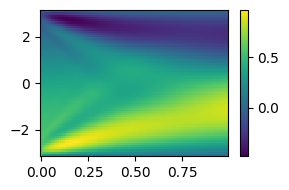

In [3]:

i = 6
s = Xs[i].transpose()
xx_mesh, tt_mesh = np.meshgrid(xs, ts)
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
fig.set_tight_layout(True)
pcm = ax.pcolormesh(tt_mesh, xx_mesh, s, vmin=s.min(), vmax=s.max())
plt.colorbar(pcm)
plt.show()
